First install STREAM

1. Need an old python env: conda create -n stream_env -c conda-forge python=3.10 -y    | See yaml for all needed packages, there are a lot
2. python -m pip install git+https://github.com/pinellolab/STREAM.git
3. Use stream_env kernel

Use my yaml file + 3 pip packages:
  - rpy2==3.6.7
  - rpy2-robjects==3.6.5
  - stream==1.1
  - networkx==2.5

In [37]:
#load stream to check all is good
import stream as st
st.__version__

'1.1'

Full pipeline like in the github tutorial: https://github.com/pinellolab/STREAM/blob/master/tutorial/1.1.STREAM_scRNA-seq%20(Bifurcation).ipynb

3.6.7


/Users/alicedecugis/miniconda3/envs/stream_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


Saving results in: /Users/alicedecugis/Desktop/hematopoiesis/stream_result
AnnData object with n_obs × n_vars = 4768 × 1656
    uns: 'workdir'
filter cells based on min_n_features
after filtering out low-quality cells: 
4277 cells, 1656 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
4277 cells, 1656 genes
83 variable genes are selected
feature var_genes is being used ...
4 cpus are being used ...


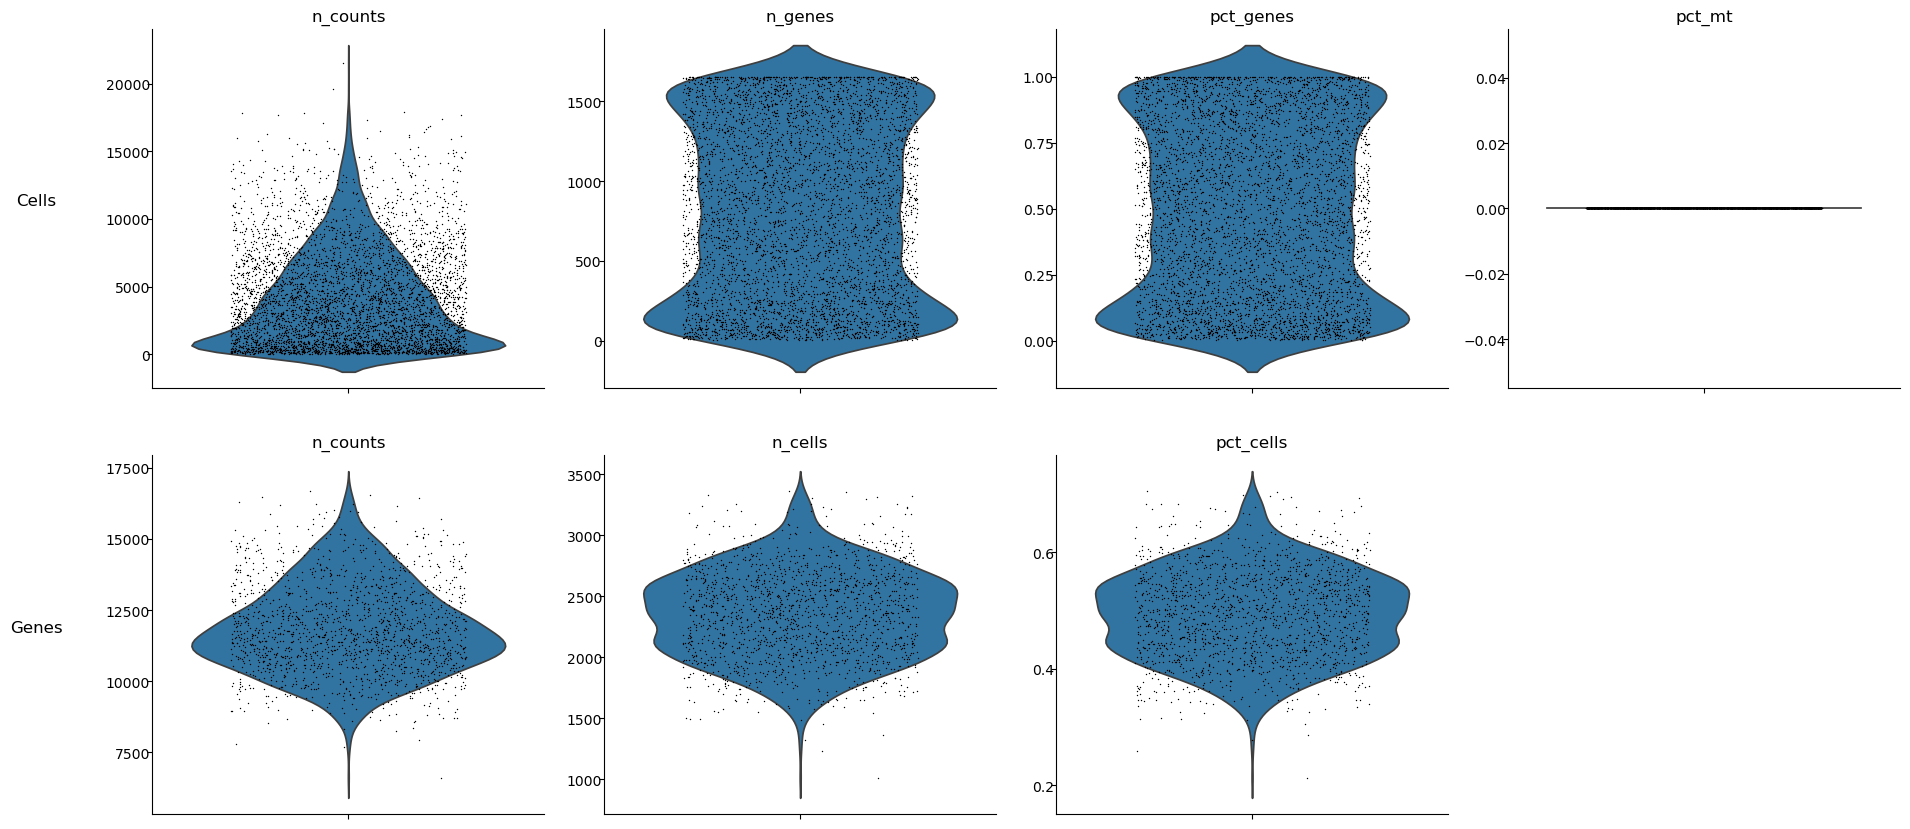

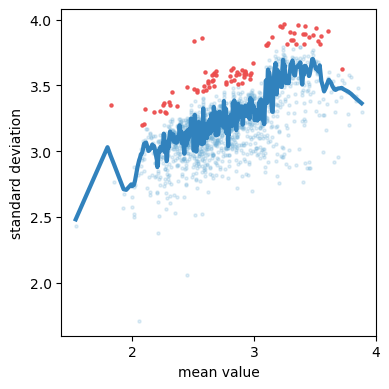

In [38]:
import pandas as pd
import stream as st
import importlib.metadata
print(importlib.metadata.version("rpy2"))
import rpy2.robjects.pandas2ri as pandas2ri
pandas2ri.activate = lambda: None
import numpy as np
import pandas as pd
from rpy2.robjects import numpy2ri, pandas2ri
from rpy2.robjects.conversion import localconverter
import rpy2.robjects as ro

# ---------------------------
# 1. Load your data
# ---------------------------
input_file = "/Users/alicedecugis/Desktop/hematopoiesis/data/nestorowa_singlecell_raw_data.tsv"

df = pd.read_csv(
    input_file,
    sep="\t",
    index_col=0
)

# genes × cells → cells × genes
df = df.T

# Save STREAM-compatible matrix
stream_input = "/Users/alicedecugis/Desktop/hematopoiesis/data/data_nestorowa_for_stream.tsv"
df.to_csv(stream_input, sep="\t")


# ---------------------------
# 2. Read into STREAM
# ---------------------------
adata = st.read(
    file_name=stream_input,
    workdir="/Users/alicedecugis/Desktop/hematopoiesis/stream_result"
)

adata.var_names_make_unique()
adata.obs_names_make_unique()

print(adata)


# ---------------------------
# 3. QC
# ---------------------------
st.cal_qc(adata, assay='rna')
st.plot_qc(adata, jitter=0.3)

st.filter_cells(adata, min_n_features=100)
st.filter_features(adata, min_n_cells=5)


# ---------------------------
# 4. NORMALIZATION
# ---------------------------
# ONLY run these once we establish
# whether your input is raw or already normalized.

# st.normalize(adata, method='lib_size')
# st.log_transform(adata)
# st.remove_mt_genes(adata)


# ---------------------------
# 5. Variable genes
# ---------------------------
st.select_variable_genes(
    adata,
    loess_frac=0.01,
    percentile=95
)


# ---------------------------
# 6. Dimension reduction
# ---------------------------
st.dimension_reduction(
    adata,
    method='se',
    feature='var_genes',
    n_components=2,
    n_neighbors=15,
    n_jobs=4
)


In [39]:
import networkx as nx

# Compatibility patch for STREAM 1.0
nx.Graph.node = property(lambda G: G._node)
nx.DiGraph.node = property(lambda G: G._node)
nx.MultiGraph.node = property(lambda G: G._node)
nx.MultiDiGraph.node = property(lambda G: G._node)
ro.r('library(ElPiGraph.R)')

# STREAM 1.0 expects the old API
pandas2ri.activate = lambda: None

# Enable NumPy → R conversion for STREAM
ro.default_converter += numpy2ri.converter

# ---------------------------
# 7. Trajectory
# ---------------------------
st.seed_elastic_principal_graph(
    adata,
    n_clusters=10
)

st.elastic_principal_graph(
    adata,
    epg_alpha=0.01,
    epg_mu=0.05,
    epg_lambda=0.05
)

Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 10
Calculatng minimum spanning tree...
Number of initial branches: 1
Learning elastic principal graph...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 50 nodes on 4277 points and 2 dimensions"
[1] "Using a single core"
Nodes = 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
1||50	2.216e-06	50	49	46	1	0	0	8.01e-07	7.774e-07	0.9748	0.9756	1.365e-06	4.933e-08	2.467e-06	0.0001233	0
11.648 sec elapsed
[[1]]
Ignoring unknown labels:
• linetype : ""

TYPE epg_obj: <class 'rpy2.rlike.container.NamedList'>
TYPE epg_obj[0]: <class 'rpy2.rlike.container.NamedList'>
epg_obj[0]: <rpy2.rlike.container.NamedList object at 0x28cd17eb0>
NAMES epg_obj[0]: <bound method NamedList.names of <rpy2.rlike.contain

In [41]:
import anndata as ad

adata = ad.AnnData(df)

adata.var_names_make_unique()
adata.obs_names_make_unique()

print(adata.shape)

print(adata.obs_names[:5])
print(adata.var_names[:5])

(1656, 4768)
Index(['HSPC_025', 'HSPC_031', 'HSPC_037', 'LT-HSC_001', 'HSPC_001'], dtype='object')
Index(['Clec1b', 'Kdm3a', 'Coro2b', '8430408G22Rik', 'Clec9a'], dtype='object')


In [43]:
st.set_workdir(adata, './stream_result')
print(adata.uns['workdir'])

Saving results in: ./stream_result
./stream_result


filter cells based on min_n_features
after filtering out low-quality cells: 
1656 cells, 4764 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
1656 cells, 4764 genes
239 variable genes are selected
feature var_genes is being used ...
4 cpus are being used ...
(1656, 2)
Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 10
Calculatng minimum spanning tree...
Number of initial branches: 1
Learning elastic principal graph...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 50 nodes on 1656 points and 2 dimensions"
[1] "Using a single core"
Nodes = 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 
BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD
1||50	6.059e-06	50	49	46	1	0	0	2.595e-06	2.502e-06	0.9702	0.9712	3.347e-06	1.171e-07	5.853e-06	0.0002926	0
7.738 sec ela

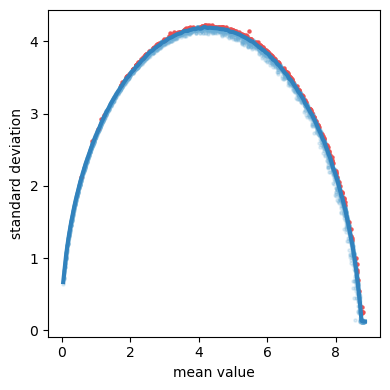

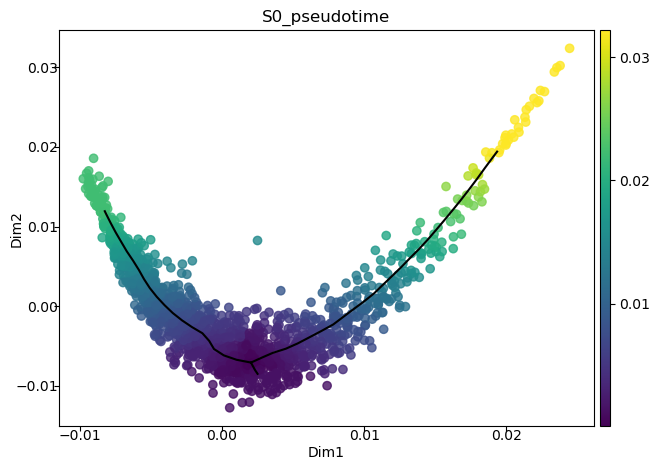

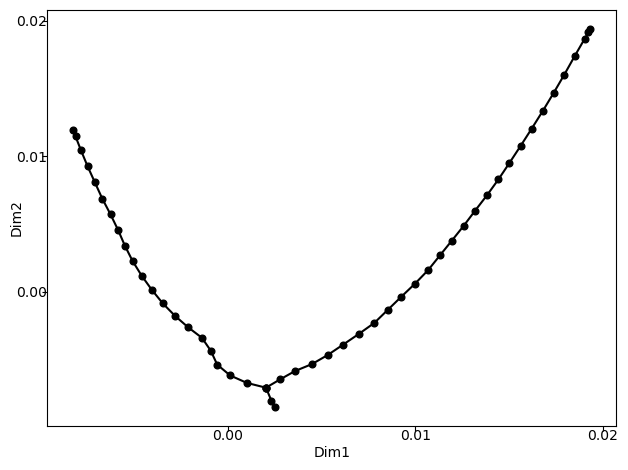

In [46]:
# ---------------------------
# 8. Plot
# ---------------------------

st.cal_qc(adata, assay='rna')

st.filter_cells(adata, min_n_features=100)
st.filter_features(adata, min_n_cells=5)

st.normalize(adata, method='lib_size')
st.log_transform(adata)
st.remove_mt_genes(adata)

st.select_variable_genes(
    adata,
    loess_frac=0.01,
    percentile=95
)

st.dimension_reduction(
    adata,
    method='se',
    feature='var_genes',
    n_components=2,
    n_neighbors=15,
    n_jobs=4
)

print(adata.obsm['X_dr'].shape)

st.seed_elastic_principal_graph(
    adata,
    n_clusters=10
)

st.elastic_principal_graph(
    adata,
    epg_alpha=0.01,
    epg_mu=0.05,
    epg_lambda=0.05
)

st.plot_dimension_reduction(
    adata,
    color=['S0_pseudotime'],
    show_graph=True,
    show_text=False
)

st.plot_branches(
    adata,
    show_text=False
)

Expression matrix: (1656, 4768)
Cells: 1656
Genes: 4768
Saving results in: /Users/alicedecugis/Desktop/hematopoiesis/stream_result
AnnData object with n_obs × n_vars = 1656 × 4768
    uns: 'workdir'
filter cells based on min_n_features
after filtering out low-quality cells: 
1656 cells, 4768 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
1656 cells, 4764 genes
239 variable genes are selected
Number of variable genes: 239
feature var_genes is being used ...
4 cpus are being used ...
Dimension reduction: (1656, 2)
Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 10
Calculatng minimum spanning tree...
Number of initial branches: 1
Learning elastic principal graph...
[1] "Constructing tree 1 of 1 / Subset 1 of 1"
[1] "Computing EPG with 50 nodes on 1656 points and 2 dimensions"
[1] "Using a single core"
Nodes = 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 

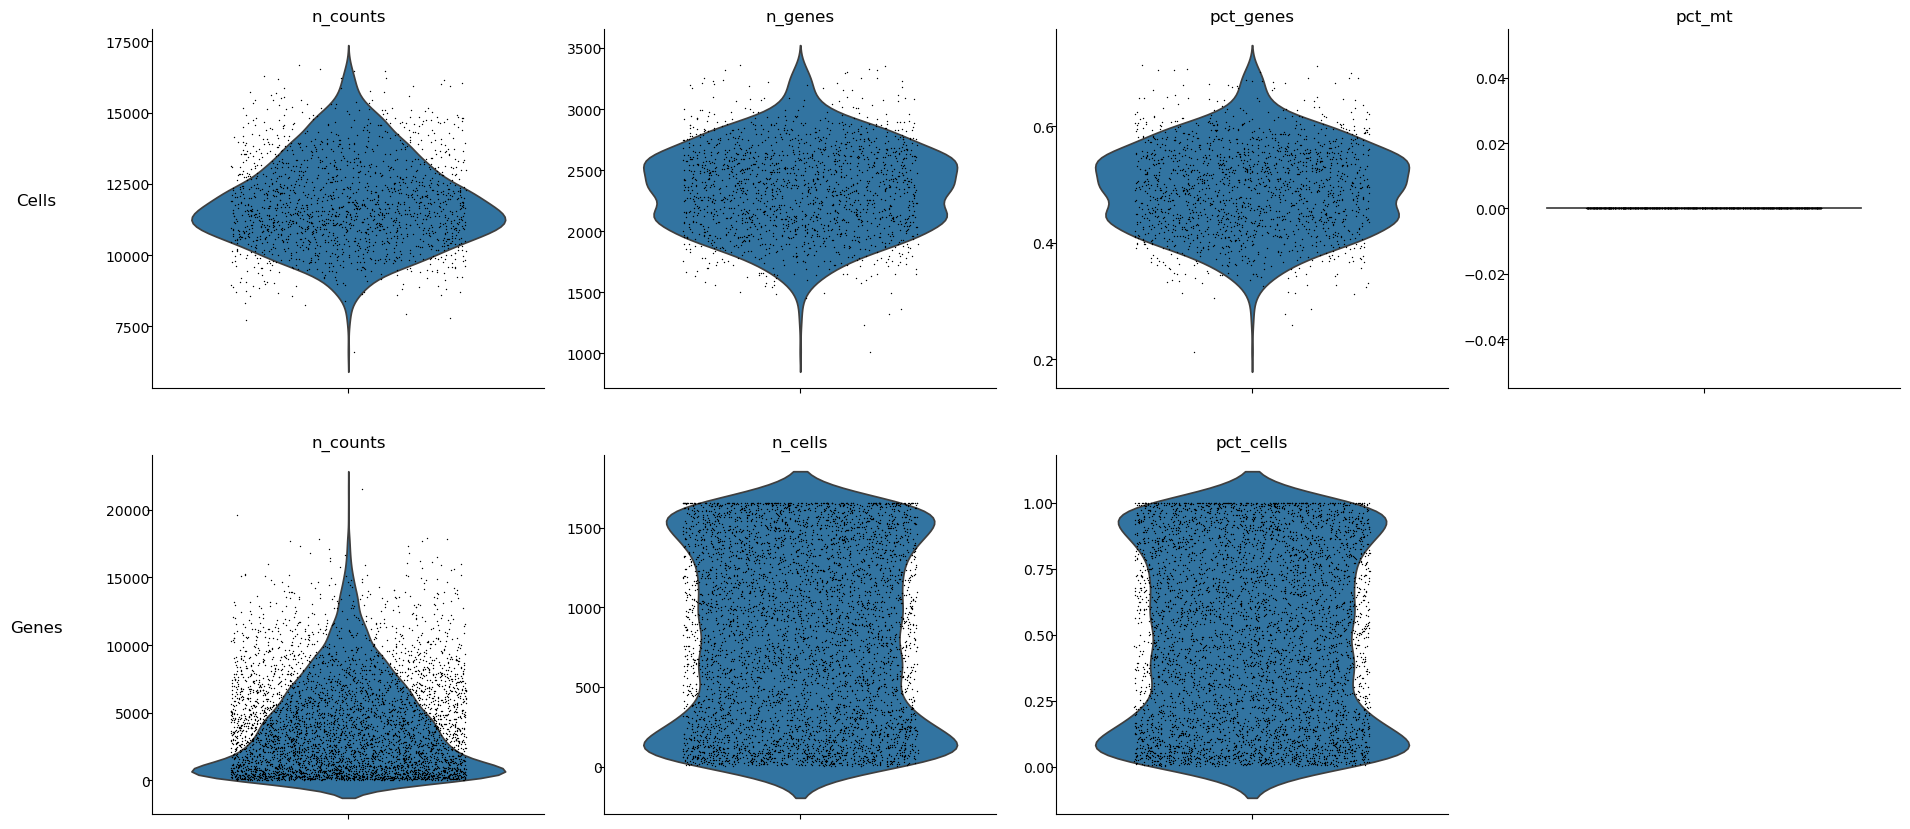

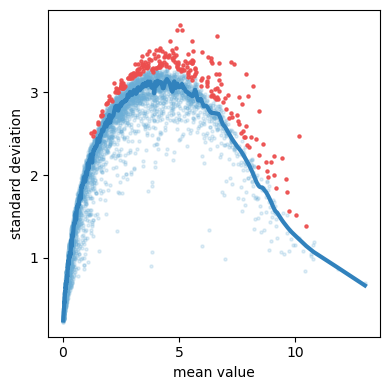

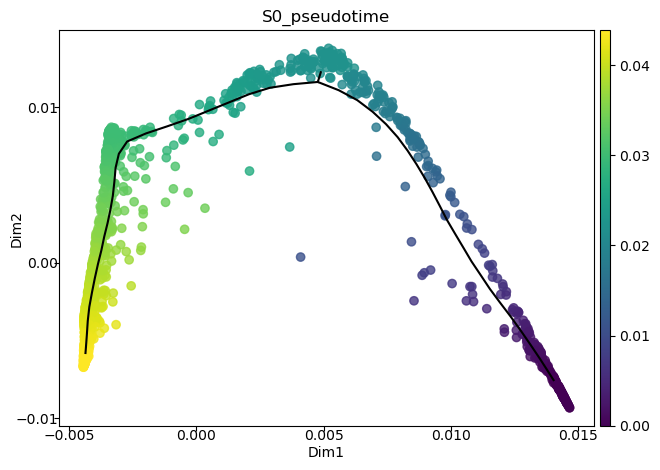

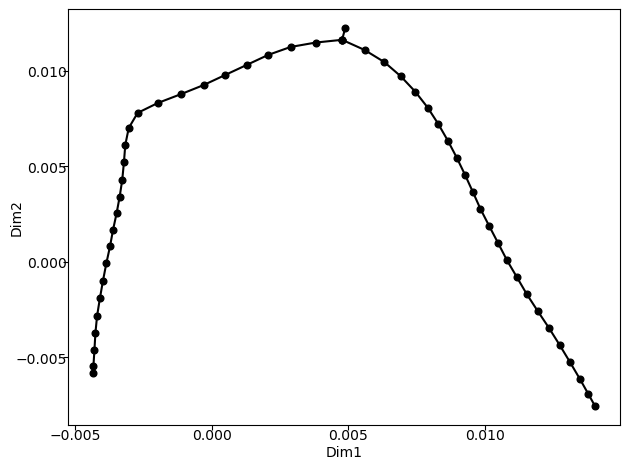

In [47]:
# ============================================================
# STREAM analysis — Nestorowa single-cell data
# ============================================================

import pandas as pd
import numpy as np
import anndata as ad
import stream as st
import networkx as nx
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, pandas2ri

# ------------------------------------------------------------
# 1. Compatibility fixes for STREAM 1.0
# ------------------------------------------------------------

# STREAM 1.0 expects the old NetworkX API
nx.Graph.node = property(lambda G: G._node)
nx.DiGraph.node = property(lambda G: G._node)
nx.MultiGraph.node = property(lambda G: G._node)
nx.MultiDiGraph.node = property(lambda G: G._node)

# STREAM 1.0 uses an old rpy2 conversion API
pandas2ri.activate = lambda: None
ro.default_converter += numpy2ri.converter

# Make sure ElPiGraph.R is available
ro.r('library(ElPiGraph.R)')

# ------------------------------------------------------------
# 2. Load Nestorowa data
# ------------------------------------------------------------

input_file = (
    "/Users/alicedecugis/Desktop/hematopoiesis/data/"
    "nestorowa_singlecell_raw_data.tsv"
)

df = pd.read_csv(
    input_file,
    sep="\t",
    index_col=0
)

# Original data: genes × cells
# STREAM needs: cells × genes
df = df.T

print("Expression matrix:", df.shape)
print("Cells:", df.shape[0])
print("Genes:", df.shape[1])

# ------------------------------------------------------------
# 3. Create AnnData
# ------------------------------------------------------------

adata = ad.AnnData(df)

adata.var_names_make_unique()
adata.obs_names_make_unique()

# STREAM output directory
st.set_workdir(
    adata,
    "/Users/alicedecugis/Desktop/hematopoiesis/stream_result"
)

print(adata)

# ------------------------------------------------------------
# 4. QC
# ------------------------------------------------------------

st.cal_qc(adata, assay="rna")

st.plot_qc(
    adata,
    jitter=0.3
)

st.filter_cells(
    adata,
    min_n_features=100
)

st.filter_features(
    adata,
    min_n_cells=5
)

# ------------------------------------------------------------
# 5. Normalization
# ------------------------------------------------------------
# IMPORTANT:
# The Nestorowa matrix appears to already contain transformed
# expression values, so we are NOT applying STREAM's
# lib-size normalization or log transformation here.
#
# If we later establish that these are raw counts, uncomment:
#
# st.normalize(adata, method="lib_size")
# st.log_transform(adata)
# st.remove_mt_genes(adata)

# ------------------------------------------------------------
# 6. Select variable genes
# ------------------------------------------------------------

st.select_variable_genes(
    adata,
    loess_frac=0.01,
    percentile=95
)

print(
    "Number of variable genes:",
    len(adata.uns["var_genes"])
)

# ------------------------------------------------------------
# 7. Dimension reduction
# ------------------------------------------------------------

st.dimension_reduction(
    adata,
    method="se",
    feature="var_genes",
    n_components=2,
    n_neighbors=15,
    n_jobs=4
)

print(
    "Dimension reduction:",
    adata.obsm["X_dr"].shape
)

# ------------------------------------------------------------
# 8. Seed elastic principal graph
# ------------------------------------------------------------

st.seed_elastic_principal_graph(
    adata,
    n_clusters=10
)

# ------------------------------------------------------------
# 9. Learn elastic principal graph
# ------------------------------------------------------------

st.elastic_principal_graph(
    adata,
    epg_alpha=0.01,
    epg_mu=0.05,
    epg_lambda=0.05
)

# ------------------------------------------------------------
# 10. Plot trajectory
# ------------------------------------------------------------

st.plot_dimension_reduction(
    adata,
    color=["S0_pseudotime"],
    show_graph=True,
    show_text=False
)

st.plot_branches(
    adata,
    show_text=False
)

print("STREAM analysis complete.")